# Dane z eyetrackera

In [1]:
%matplotlib inline

In [2]:
import pandas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Wczytanie danych

In [3]:
fname = '../data/eye_tracking/raw/KFD1.txt'
df = pandas.read_table(fname)

In [4]:
df.head()

,trial,buf_index,pos_time,pos_x,pos_y,pup_time,pup_diameter,marker
0,1,1,2433,13.056278,-9.549029,2433,4.375438,0
1,1,2,2447,12.585640,-23.112649,2447,4.280790,0
2,1,3,2450,12.279797,-24.893367,2450,4.263669,0
3,1,4,2453,11.317062,-23.571532,2453,4.268221,0
4,1,5,2457,10.681858,-24.828672,2457,4.272300,0


## Rysowanie ruchu oka w wybranym trialu

1 - wykład; 2 - budynek, 3 - twarz, 4 - twarz, 5 - tekst

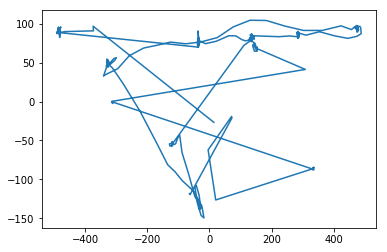

In [5]:
trial_number = 5
fragment = df[df.trial == trial_number]

plt.plot(fragment.pos_x, fragment.pos_y)

## Sakkady przy czytaniu

Text(0,0.5,'Pozycja x [px]')

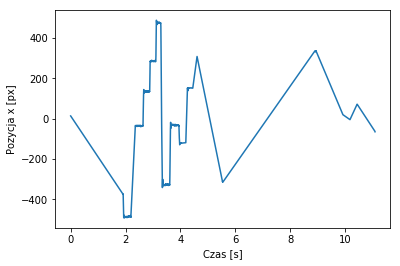

In [6]:
trial_number = 5
fragment = df[df.trial == trial_number]
tm = (fragment.pos_time - fragment.pos_time.iloc[0]) / 1000
plt.plot(tm, fragment.pos_x)
plt.xlabel('Czas [s]')
plt.ylabel('Pozycja x [px]')

## Spojrzenie nałożone na zdjęcie

In [7]:
def plot_gaze(trial_data, stimulus_file, gaze_color='red'):
    img = mpimg.imread(stimulus_file)
    w = img.shape[1]
    h = img.shape[0]
    
    plt.figure(figsize=(12, 10))
    plt.imshow(img, extent=(-w/2, w/2, -h/2, h/2))
    plt.plot(trial_data.pos_x, trial_data.pos_y, color=gaze_color)
    plt.show()

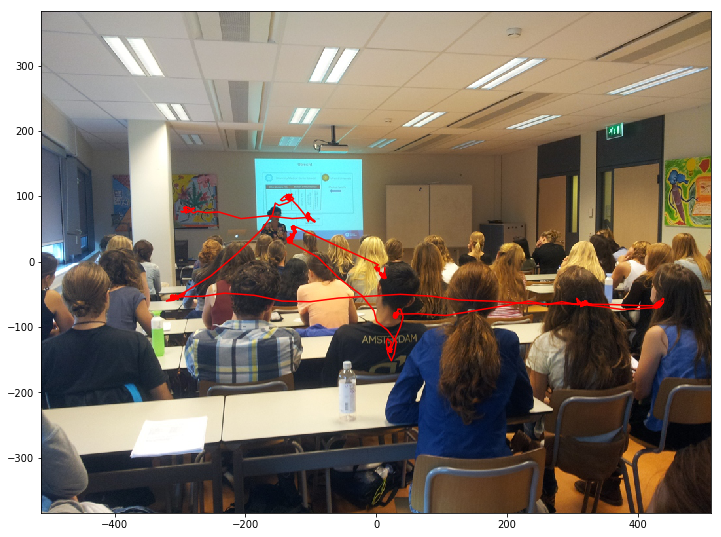

In [8]:
plot_gaze(df[df.trial == 1], '../data/eye_tracking/stimuli/lecture.jpg')

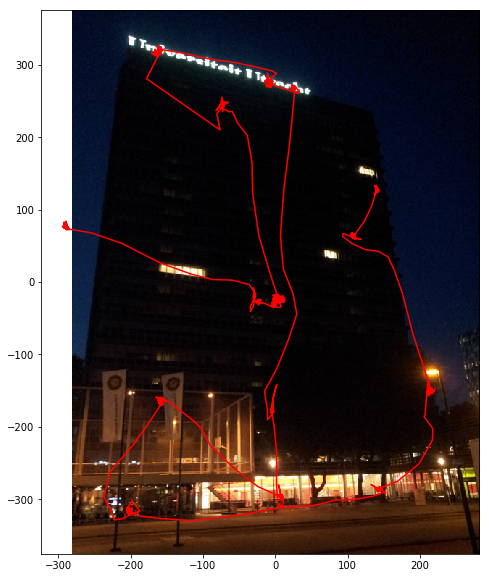

In [9]:
plot_gaze(df[df.trial == 2], '../data/eye_tracking/stimuli/vanunnik.jpg')

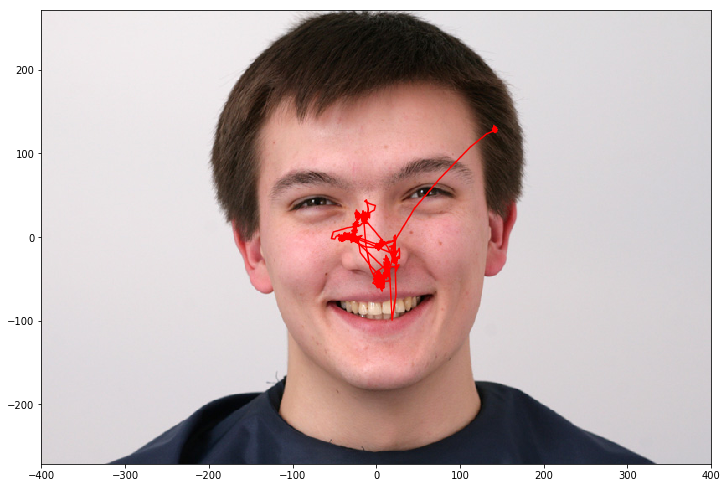

In [10]:
plot_gaze(df[df.trial == 3], '../data/eye_tracking/stimuli/JG_0024-lo.jpg')

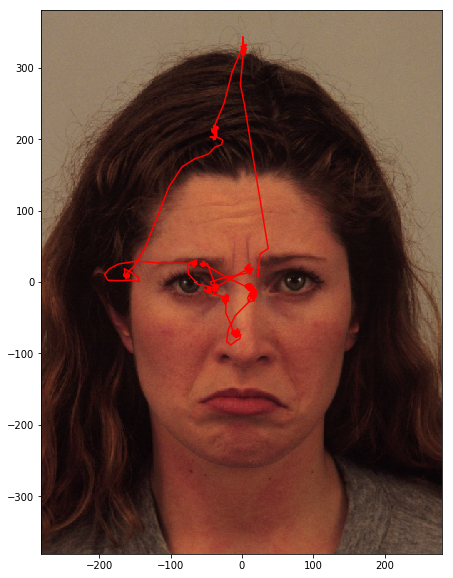

In [11]:
plot_gaze(df[df.trial == 4], '../data/eye_tracking/stimuli/AF11SAS.jpg')

Inspirowane http://www.pygaze.org/2015/06/pygaze-analyser/